# Architecture

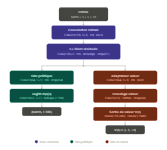

Le schéma couvre l'intégralité du réseau. Quelques points clés à retenir :

Tronc commun (violet) — shared entre les deux têtes. La convolution initiale extrait les features locales (motifs 3×3 sur le plateau), puis les 5 blocs résiduels approfondissent la représentation sans souffrir du vanishing gradient grâce aux skip connections. Le Dropout(0.1) léger laisse le gradient circuler librement.

Tête politique (vert-bleu) — produit 1 300 logits bruts (5×5×52), un score par combinaison pièce × mouvement. Le masque des coups invalides est appliqué après le réseau, via le -1e9 que tu ajoutes dans play(). Le Dropout(0.4) plus agressif régularise la tête qui est davantage exposée à l'overfitting (espace de sortie très large).

Tête de valeur (corail) — contrairement à la politique, elle passe par un value_adapter Conv2D(64) séparé avant de réduire à 16 canaux, aplatir, puis traverser deux couches Dense. Cela lui donne une "route" distincte depuis les features du tronc, ce qui est utile quand tu gèles le tronc (entraînement supervisé policy-only) : la tête de valeur peut se spécialiser sans interférer.